In [1]:
import pandas as pd

df = pd.DataFrame({
    'age': [25, 32, 45, 29, 38],
    'job': ['Developer', 'Teacher', 'Developer', 'Doctor', 'Teacher'],
    'city': ['Tel Aviv', 'Haifa', 'Jerusalem', 'Haifa', 'Tel Aviv'],
    'salary': [15000, 12000, 22000, 18000, 16000]
})

X = df.drop(columns=['salary'])
y = df['salary']

X = pd.get_dummies(
    X,
    columns=['job', 'city'],
    dtype=int
)

X

,age,job_Developer,job_Doctor,job_Teacher,city_Haifa,city_Jerusalem,city_Tel Aviv
0,25,1,0,0,0,0,1
1,32,0,0,1,1,0,0
2,45,1,0,0,0,1,0
3,29,0,1,0,1,0,0
4,38,0,0,1,0,0,1


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Fruit data
colors  = np.array([200, 50, 220, 240, 250, 230, 30, 40, 20])
sizes   = np.array([7, 7, 6, 9, 8, 9, 12, 13, 11])
weights = np.array([150, 160, 140, 170, 165, 180, 120, 130, 115])

fruit_types = np.array([
    'apple', 'apple', 'apple',
    'orange', 'orange', 'orange',
    'banana', 'banana', 'banana'
])

X = np.column_stack((colors, sizes, weights))
y = fruit_types

# Create pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])

# Cross-validation
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=3,
    scoring='accuracy'
)

print("--- Cross-Validation Results ---")
print("Scores:", scores)
print(f"Average Accuracy: {scores.mean():.2f}")

# Train final model on all data
# pipeline.fit(X, y

--- Cross-Validation Results ---
Scores: [0.66666667 1.         0.66666667]
Average Accuracy: 0.78


In [3]:
import numpy as np

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# --------------------------------------------------
# Data - 24 examples, 2 features
# --------------------------------------------------

X = np.array([
    # Class 0
    [1.0, 1.0],
    [1.2, 1.5],
    [1.5, 1.2],
    [1.8, 1.7],
    [2.0, 1.3],
    [2.2, 2.0],
    [2.5, 1.5],
    [2.7, 2.2],
    [3.0, 1.8],
    [3.2, 2.5],
    [3.5, 2.0],
    [3.7, 2.8],

    # Class 1
    [5.0, 5.0],
    [5.2, 5.5],
    [5.5, 5.2],
    [5.8, 6.0],
    [6.0, 5.5],
    [6.2, 6.3],
    [6.5, 5.8],
    [6.8, 6.5],
    [7.0, 6.0],
    [7.2, 7.0],
    [7.5, 6.5],
    [7.8, 7.2]
])

y = np.array([
    0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0,
    1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1
])

# --------------------------------------------------
# Pipeline
# --------------------------------------------------

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# --------------------------------------------------
# Hyperparameters to test
# --------------------------------------------------

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.01, 0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

# --------------------------------------------------
# Grid Search + Cross Validation
# --------------------------------------------------

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1  # use all available CPU cores 
)

grid.fit(X, y)

'''
i.e. knn:
param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11]
}

# Grid Search
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy'
)
'''

# --------------------------------------------------
# Results
# --------------------------------------------------

print("Best parameters:")
print(grid.best_params_)

print("\nBest cross-validation accuracy:")
print(grid.best_score_)

Best parameters:
{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}

Best cross-validation accuracy:
1.0


Best degree: 3
Best MSE: 0.7153780577545237


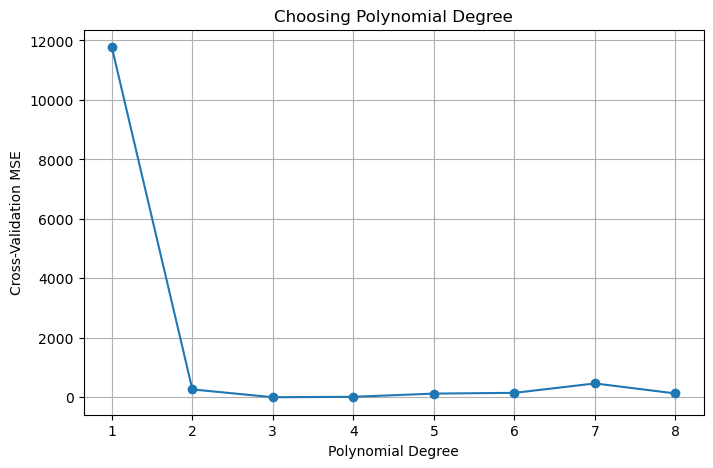

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV  # <- יבוא חסר שהתווסף
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# --------------------------------------------------
# Data - 30 observations
# --------------------------------------------------

X = np.array([
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
    21, 22, 23, 24, 25, 26, 27, 28, 29, 30
]).reshape(-1, 1)

y = np.array([
    5, 8, 12, 15, 18, 24, 30, 38, 45, 55,
    67, 80, 95, 110, 128, 147, 168, 190, 215, 240,
    268, 298, 330, 365, 402, 440, 481, 524, 570, 618
])

# --------------------------------------------------
# Try different polynomial degrees
# --------------------------------------------------

# Pipeline
model = Pipeline([
    ('poly', PolynomialFeatures()),
    ('regression', LinearRegression())
])

# Degrees to test
param_grid = {
    'poly__degree': range(1, 9)
}

# Grid Search + Cross Validation
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid.fit(X, y)

# Best result
print("Best degree:", grid.best_params_['poly__degree'])
print("Best MSE:", -grid.best_score_)

# --------------------------------------------------
# Plot Degree vs Error
# --------------------------------------------------

degrees = list(param_grid['poly__degree'])
errors = -grid.cv_results_['mean_test_score']  # הפיכת הערכים לחיוביים (MSE)

plt.figure(figsize=(8, 5))

plt.plot(degrees, errors, marker='o')

plt.xlabel("Polynomial Degree")
plt.ylabel("Cross-Validation MSE")
plt.title("Choosing Polynomial Degree")

plt.xticks(degrees)
plt.grid(True)

plt.show()

In [5]:
import numpy as np
import joblib

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# --------------------------------------------------
# Data
# --------------------------------------------------

X = np.array([
    [200, 7, 150],
    [50,  7, 160],
    [220, 6, 140],
    [240, 9, 170],
    [250, 8, 165],
    [230, 9, 180],
    [30, 12, 120],
    [40, 13, 130],
    [20, 11, 115],

    [210, 7, 155],
    [60,  6, 145],
    [215, 8, 158],
    [245, 9, 175],
    [235, 8, 168],
    [255, 10, 182],
    [25, 12, 118],
    [35, 14, 125],
    [45, 11, 128]
])

y = np.array([
    'apple', 'apple', 'apple',
    'orange', 'orange', 'orange',
    'banana', 'banana', 'banana',

    'apple', 'apple', 'apple',
    'orange', 'orange', 'orange',
    'banana', 'banana', 'banana'
])

# --------------------------------------------------
# Pipeline
# --------------------------------------------------

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier())
])

# --------------------------------------------------
# Grid Search
# Test K + distance metric
# --------------------------------------------------

param_grid = {
    'knn__n_neighbors': [1, 3, 5],
    'knn__metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy'
)

# --------------------------------------------------
# Cross-validation + training
# --------------------------------------------------

grid.fit(X, y)

print("Best parameters:")
print(grid.best_params_)

print("Best CV accuracy:")
print(grid.best_score_)

# --------------------------------------------------
# Get best pipeline
# --------------------------------------------------

best_model = grid.best_estimator_

# --------------------------------------------------
# Save scaler + model together
# --------------------------------------------------

joblib.dump(best_model, 'knn_fruit_model.pkl')

print("Model saved.")

Best parameters:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 1}
Best CV accuracy:
1.0
Model saved.


In [6]:
# --------------------------------------------------
# Load model from file
# --------------------------------------------------

loaded_model = joblib.load('knn_fruit_model.pkl')

# --------------------------------------------------
# Predict NEW observation
# IMPORTANT: Give RAW values, NOT scaled values
# --------------------------------------------------

new_fruit = np.array([
    [225, 7, 150]
])

prediction = loaded_model.predict(new_fruit)

print("Prediction:", prediction[0])

Prediction: apple


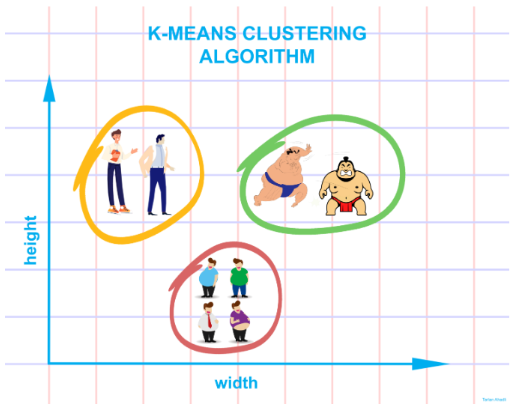